Sources -
* For sequence aware recommendation ideas - https://github.com/mquad/sars_tutorial
* For using surprise package - https://realpython.com/build-recommendation-engine-collaborative-filtering/


# Overview

1. **Collaborative filtering** - Harnessing quality judgements of other users. Here we look what other similar users have done to recommend   
Here we just use the interaction data
    1. **Memory based** - Uses the full user x item matrix
        1. User x User
        2. Item x Item
    2. **Model based** - Tries to reduce the sparse user x item matrix into dense user x reduced dimensions and item x reduced dimensions representation using different matrix factorisation techniques like
        1. SVD
        2. SGD
    3. **Hybrid** - Model based method for dense vectors and then using distance like in memory based method
2. **Content based filtering** - Recommend items to customer x similar to previous items rated highly by x.   
Here we use item and user features


Source - https://www2.slideshare.net/FrancescoCasalegno1/recommender-systems-141047014
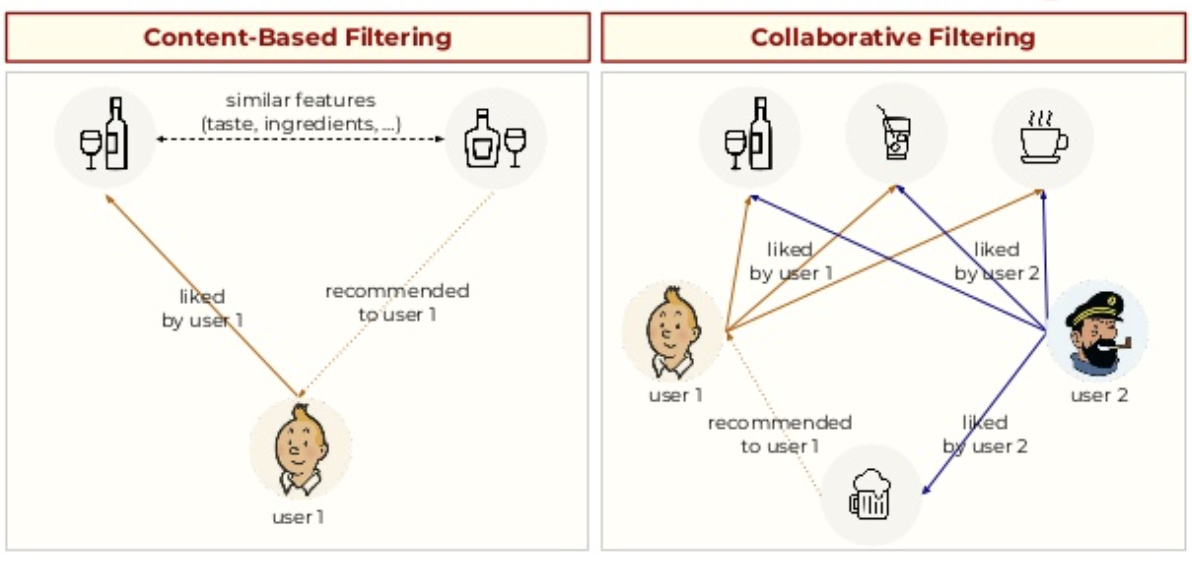

# Prepare the data

In [1]:
import pandas as pd

from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import KNNBasic, KNNWithMeans, KNNWithZScore

In [2]:
df = pd.read_csv('../../datasets/booking/booking_train_set.csv.gz')

In [3]:
df.head()

,Unnamed: 0,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
0,0,1006220,2016-04-09,2016-04-11,31114,desktop,384,Gondal,Gondal,1006220_1
1,1,1006220,2016-04-11,2016-04-12,39641,desktop,384,Gondal,Gondal,1006220_1
2,2,1006220,2016-04-12,2016-04-16,20232,desktop,384,Gondal,Glubbdubdrib,1006220_1
3,3,1006220,2016-04-16,2016-04-17,24144,desktop,384,Gondal,Gondal,1006220_1
4,4,1010293,2016-07-09,2016-07-10,5325,mobile,359,The Devilfire Empire,Cobra Island,1010293_1


#### Create a number of days feature

`stay_days` will represent rating

In [4]:
df['checkout'] = pd.to_datetime(df['checkout'])
df['checkin'] = pd.to_datetime(df['checkin'])

df['stay_days'] = (df['checkout'] - df['checkin']).dt.days

In [5]:
df.head()

,Unnamed: 0,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id,stay_days
0,0,1006220,2016-04-09,2016-04-11,31114,desktop,384,Gondal,Gondal,1006220_1,2
1,1,1006220,2016-04-11,2016-04-12,39641,desktop,384,Gondal,Gondal,1006220_1,1
2,2,1006220,2016-04-12,2016-04-16,20232,desktop,384,Gondal,Glubbdubdrib,1006220_1,4
3,3,1006220,2016-04-16,2016-04-17,24144,desktop,384,Gondal,Gondal,1006220_1,1
4,4,1010293,2016-07-09,2016-07-10,5325,mobile,359,The Devilfire Empire,Cobra Island,1010293_1,1


#### Keep the user item and rating columns

In [6]:
ratings = df[['utrip_id','city_id','stay_days','checkin']]

#### Split data into train and test

Splitting pr sampling of train and test datasets happens differently in collobarative filtering methods vs the content based methods.
* Content based methods follow the same methods we use in traditional ML models
* Collobarative filtering methods are different. They are distance or similarity based methods. So the whole train data is the seen user X item rating to which similarities are measured. The test is the unseen user x item rating for which the similairity is measured to the seen user x item, the ratings estimated and compared to the actual

Source - https://tryolabs.com/blog/introduction-to-recommender-systems/
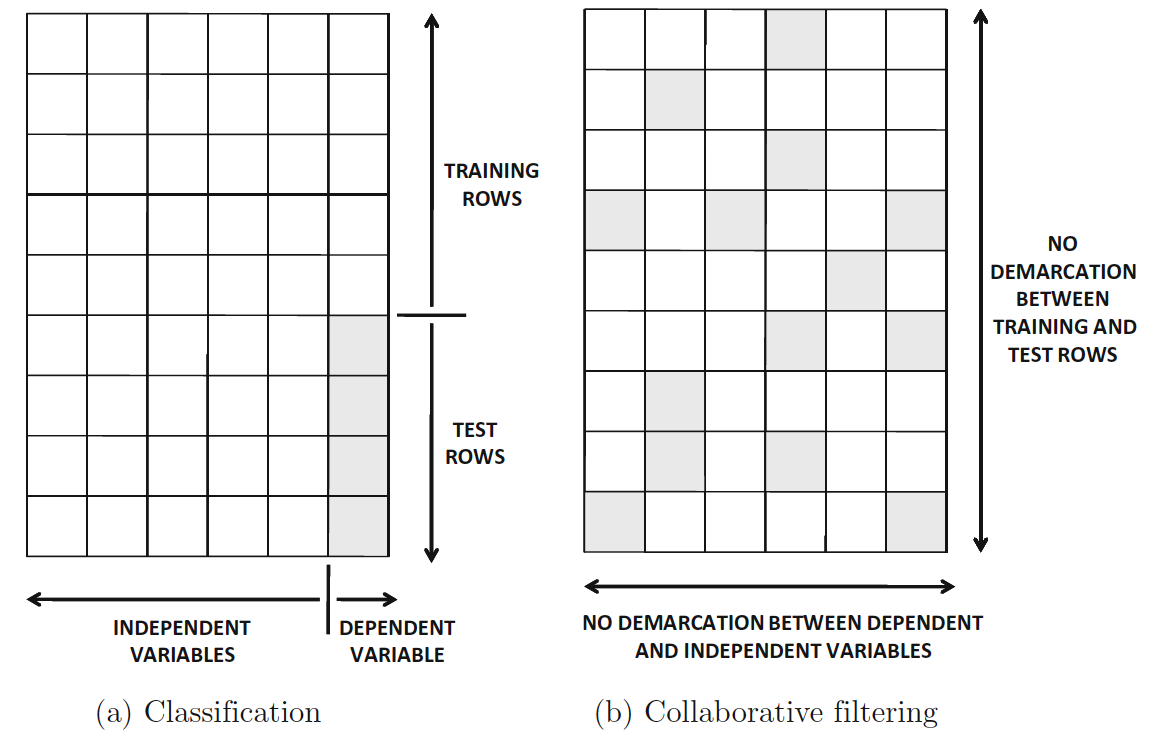

In our case we want to do splitting in a manner called 'leave one out', where we mask out one of the known ratings for a user in the train data and keep that in test.

Source - https://towardsdatascience.com/recommendation-systems-in-the-real-world-51e3948772f3
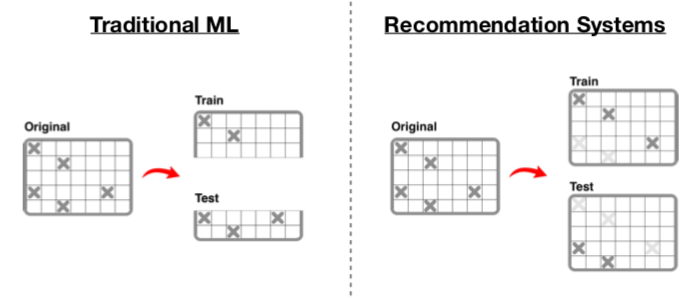

In fact, we want to do the leave one out split in a time aware manner, where we keep the last item rated in the test data

In [22]:
ratings['rank_latest'] = ratings.groupby(['utrip_id'])['checkin'].rank(method='first', ascending=False)

train_ratings = ratings[ratings['rank_latest'] != 1]
#train_ratings = ratings[ratings['rank_latest'] != 1][:100000]
test_ratings = ratings[ratings['rank_latest'] == 1]

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [23]:
print (ratings.shape,train_ratings.shape,test_ratings.shape )

(1166835, 5) (949149, 5) (217686, 5)


#### Convert the data into surprise format

In [24]:
train = train_ratings[['utrip_id','city_id','stay_days']]
train.columns=['user','item','rating']
train.index = pd.to_datetime(train_ratings['checkin'])

test = test_ratings[['utrip_id','city_id','stay_days']]
test.columns=['user','item','rating']
test.index = pd.to_datetime(test_ratings['checkin'])

In [25]:
rating_min, rating_max = min(df['stay_days']),max(df['stay_days'])

reader = Reader(line_format='user item rating timestamp', 
                sep=',',
                rating_scale = (rating_min,rating_max))

train_data = Dataset.load_from_df(train, reader=reader)
trainset = train_data.build_full_trainset()

#test_data = Dataset.load_from_df(test, reader=reader)
#testset = test_data.build_full_trainset()

# Collaborative filtering - memory based

Memory based methods rely on a measure of similarity. Similarity can be measured using -
1. Jaccard Similarity - just measures the number of ratings that match in the two sets
2. Cosine similarity
3. Pearson correlation coefficient

Note: 
* Cosine similarity tends to work best
* Cosine similarity is correlation when data is centered at 0

Source - https://www2.slideshare.net/FrancescoCasalegno1/recommender-systems-141047014
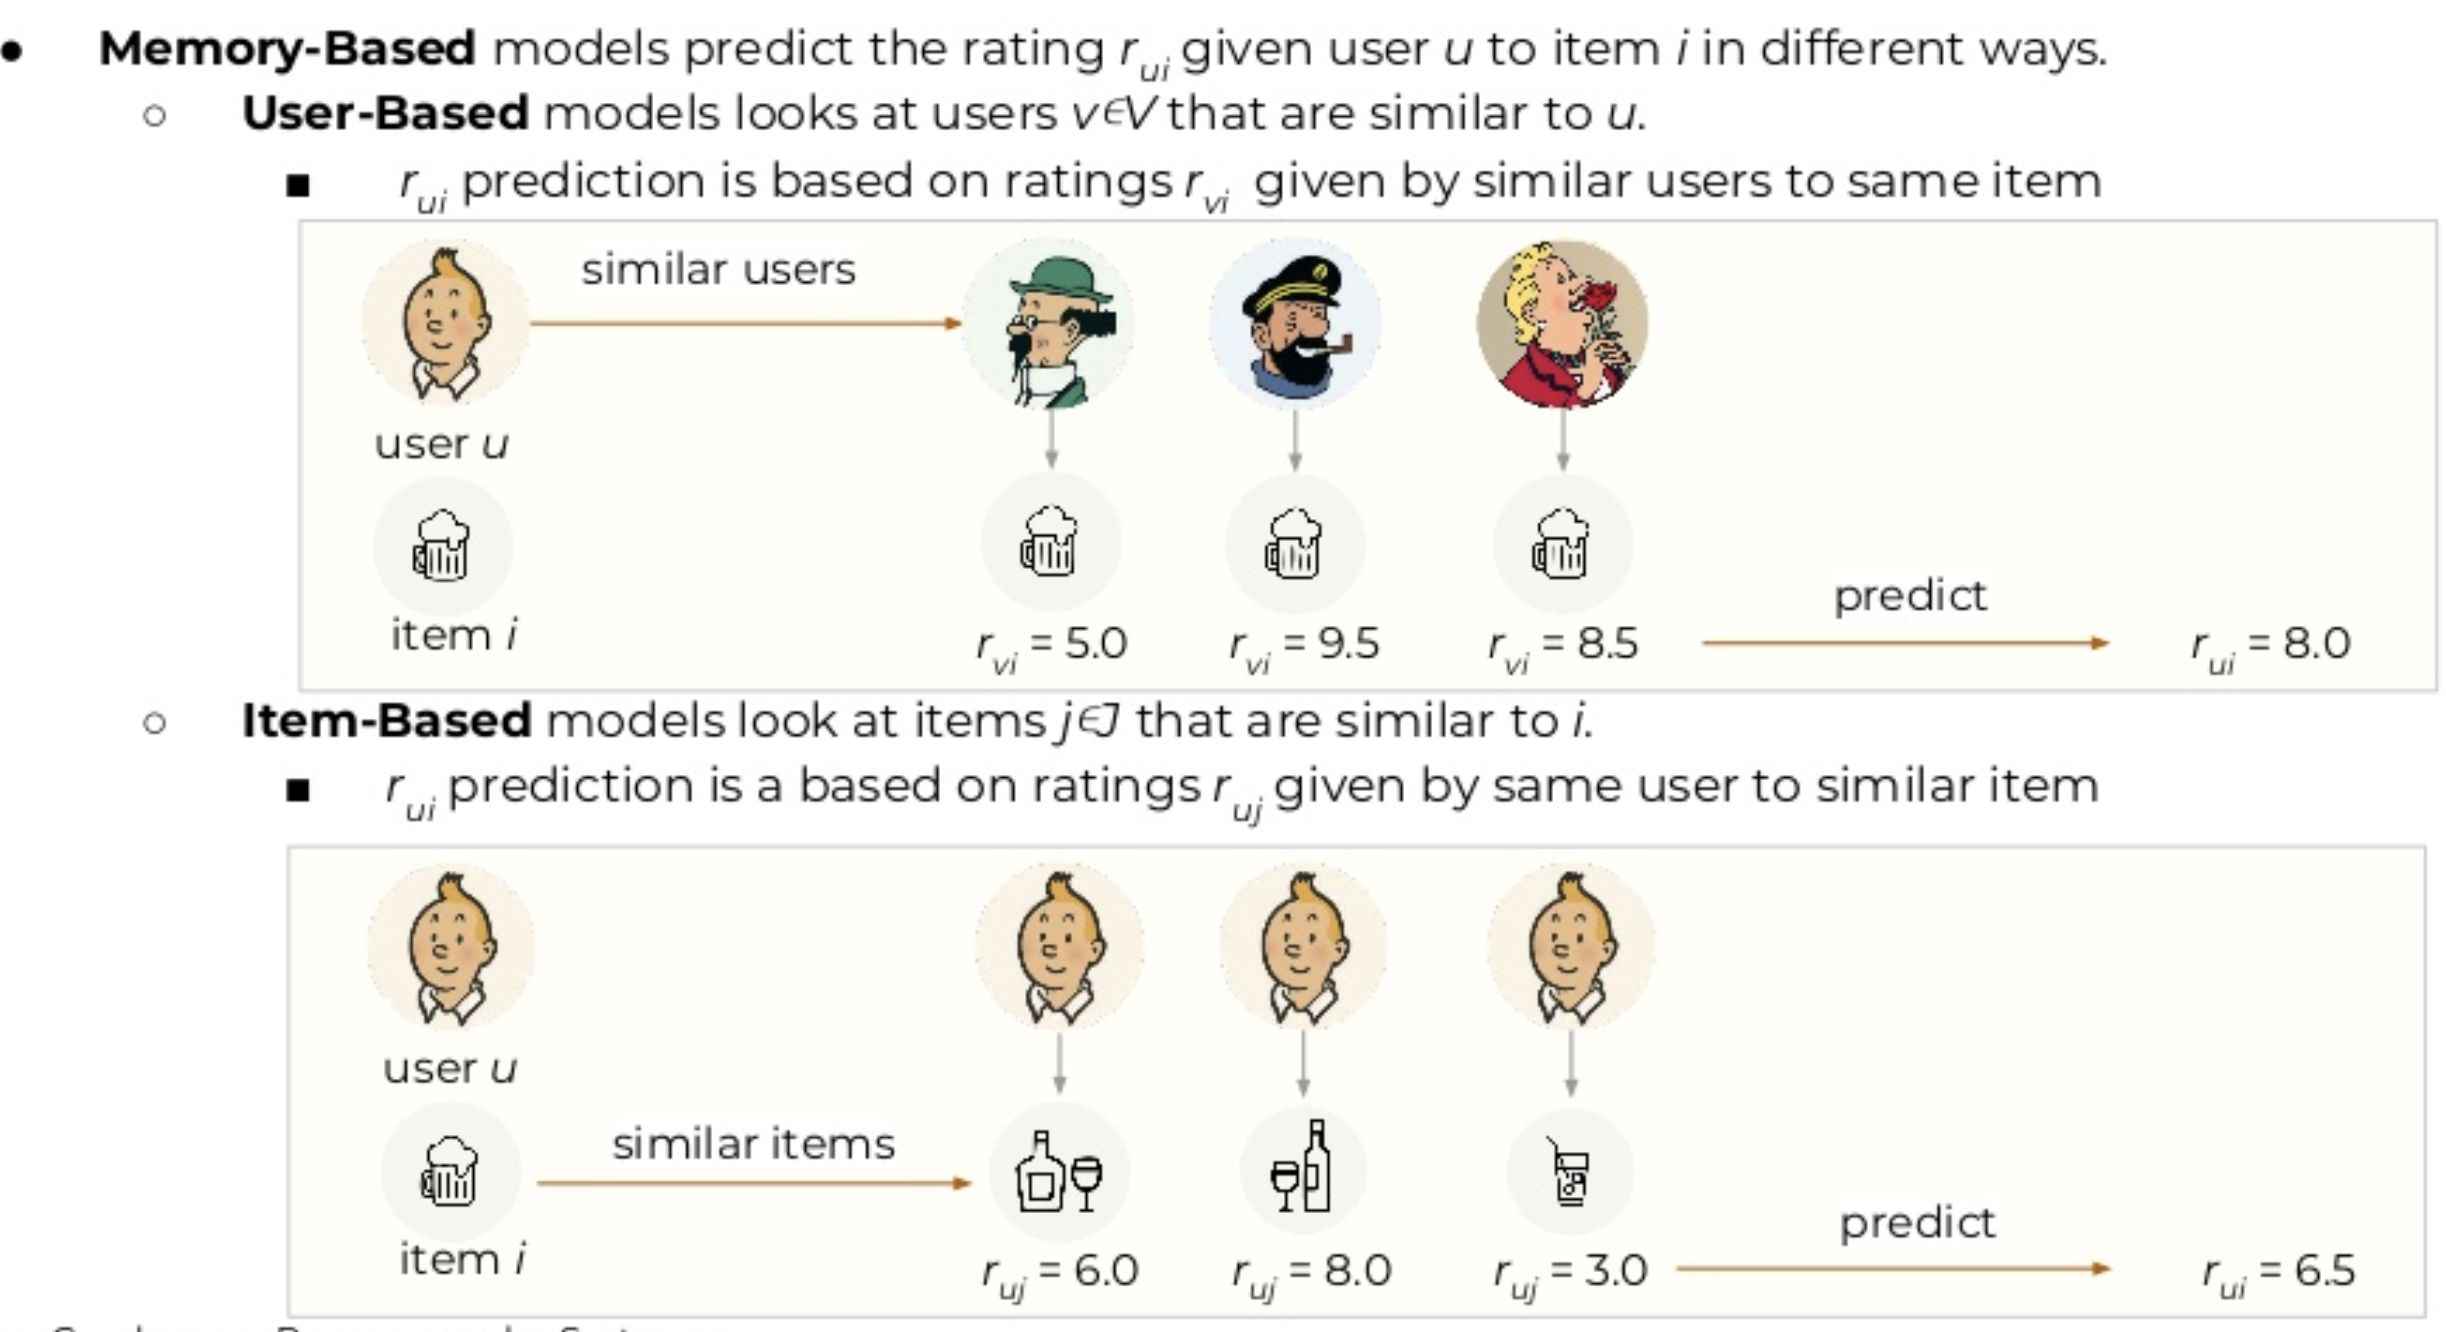

## User x User approach

1. Consider user **u**
2. Find set of **N** other users who are similar to **u** i.e, whose rating of items is similar to that of **u**
3. Estimate **u**'s rating for new item **i** based on average rating of **k** users' for item **i**

$\Large r_{ui}= \Large\frac
        {\sum_{v\in N(u)}sim_{uv}.r_{vi}} 
        {\sum_{v\in N(u)}sim_{uv}}$

In [26]:
%%time

from surprise import KNNWithMeans

my_k = 5
my_min_k = 2
my_sim_option = {
    'name':'cosine', 'user_based':False, 
    }
algo = KNNWithMeans(
    k = my_k, min_k = my_min_k, sim_option = my_sim_option
    )
algo.fit(trainset)

Computing the msd similarity matrix...


MemoryError: 

## Item x Item approach

1. Consider item **i**
2. Find set of **N** other items that are similar to **i** i.e, whose rating of across users is similar to that of **i**
3. Estimate **u**'s rating for new item **i** based on average rating of **k** similar items by user **u**

$\Large r_{ui}= \Large\frac
        {\sum_{j\in N(i)}sim_{ij}.r_{uj}} 
        {\sum_{j\in N(i)}sim_{ij}}$

In [ ]:
# Sampling of trip_ids such that there is no data leakage of users into the new other sample
# the days of stay could be like a rating in our data for building a recommendation engine

# Innovation

The recommendations in this case would benefit from the sequential order of stays in a trip (or even previous trips)